## Setup and Data Loading

In [32]:
import pandas as pd

df = pd.read_csv('diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Part A: Clustering 
#### 1. Using sklearn, apply K-Means clustering on the normalized data with k = {2, 3, 4, 5, 6, 7, 8, 9, 10, 11}, max_iter = 500. Plot the SSE (sum of squared errors) values for each number of clusters.

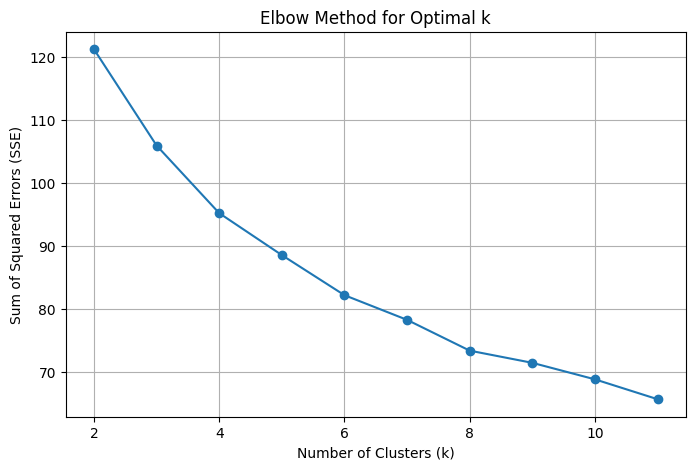

In [33]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Normalize the features using MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(X)

# Apply K-Means clustering for k = 2 to 11
sse = []
k_values = range(2, 12)

for k in k_values:
    kmeans = KMeans(n_clusters=k, max_iter=500, random_state=42)
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)  # inertia_ gives SSE

# Plot the SSE vs number of clusters
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()



#### 2. Using k=6, assign each observation to a cluster and classify them based on the majority class of the cluster they belong to (Example: If cluster A has 100 observations of class 0 and 99 observations of class 1, classify all 199 observations as the majority class: 0 ). Compute the confusion matrix, accuracy, precision, recall, and F1-score for this classification model. Is this a good classification model? Justify your answer based on your experience with classification models, and discuss the limitations of using clustering for classification tasks.

In [34]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering (k=6)
kmeans = KMeans(n_clusters=6, max_iter=500, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Assign each cluster to majority class
cluster_labels = {}
for cluster in np.unique(clusters):
    mask = (clusters == cluster)
    majority_class = y[mask].mode()[0]
    cluster_labels[cluster] = majority_class

# Predict based on majority class of cluster
y_pred = np.array([cluster_labels[c] for c in clusters])

# Compute metrics
cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

# Display results
print("Confusion Matrix:\n", cm)
print(f"\nAccuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")


Confusion Matrix:
 [[390 110]
 [119 149]]

Accuracy: 0.7018
Precision: 0.5753
Recall: 0.5560
F1-Score: 0.5655


#### Interpretation:

* **Accuracy of 0.7018%** means the model correctly classifies about 70% of all patients — whether diabetic or not.  
* **Precision (0.5753)** means that when the model predicts “diabetes,” it is correct only 57.5% of the time
* **Recall (0.5560)** means it correctly identifies only about 55% of actual diabetic patients — which is risky in healthcare, where false negatives are serious.
* **F1-score (0.5655)** summarizes both precision and recall, showing the model is not well-balanced.

#### Conclusion:

* Overall this is not a good classification model, especially for a sensitive task like diagnosing diabetes.
* The reason for the poor performance is that K-Means is not designed for classification, it’s an unsupervised algorithm.
* It groups data based on feature similarity, not on whether the patient is diabetic.
* The clusters may not align well with the true class boundaries.
* Assigning a cluster to the “majority class” is a post-hoc approximation, not a learned decision rule.
* The results demonstrate that clustering is not a substitute for supervised learning when labeled data are available.
* A better approach would be to use a logistic regression, random forest, or gradient boosting classifier, which explicitly learn the relationship between predictors and the target variable.



#### 3. Print the class distribution and the cluster centers for this model. Choose the 3 most discriminative clusters and interpret the results. What can you conclude about the patients in those clusters?

In [35]:
# Create DataFrame with clusters and actual outcome
cluster_df = pd.DataFrame(X, columns=X.columns)
cluster_df['Cluster'] = clusters
cluster_df['Outcome'] = y

# Print class distribution per cluster
class_distribution = cluster_df.groupby('Cluster')['Outcome'].value_counts().unstack(fill_value=0)
print("Class Distribution per Cluster:\n")
print(class_distribution)

# Print cluster centers (rescaled to original feature range for interpretability)
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=X.columns)
print("\nCluster Centers:\n")
print(cluster_centers.round(2))


Class Distribution per Cluster:

Outcome    0   1
Cluster         
0         61  73
1        254  26
2         43  26
3         19  16
4         74  51
5         49  76

Cluster Centers:

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0         1.88   149.47          74.47          34.19   209.57  37.07   
1         1.77    99.10          66.96          23.64    58.59  30.02   
2         5.96   135.20          80.41           5.12     8.13  29.52   
3         3.63   117.80           0.00           1.51     0.00  25.71   
4         4.82   123.06          73.74           1.65     9.21  31.80   
5         8.53   129.88          76.62          31.68   120.70  34.28   

   DiabetesPedigreeFunction    Age  
0                      0.62  29.13  
1                      0.42  25.19  
2                      0.40  56.81  
3                      0.39  30.71  
4                      0.41  32.76  
5                      0.54  43.87  


### Conclusion:

Based on dominance, the three most distinct clusters are:
* Cluster 1 — very strongly dominated by non-diabetics (254 vs 26)
* Cluster 5 — more diabetics (76 vs 49)
* Cluster 0 — slightly more diabetics (73 vs 61), but interesting due to high glucose and insulin levels

#### Interpretation of the Three Most Discriminative Clusters:

**Cluster 1** — Predominantly Non-Diabetic (Healthy Group)
* Glucose (99) and Insulin (59) are both low — near normal range.
* BMI (30) is borderline overweight.
* Age (25) is young.

Represents young, mostly healthy patients with low diabetes risk.

**Cluster 5** — Predominantly Diabetic
* High Glucose (130), BMI (34), Insulin (121), and Age (44).
* Pregnancies (8.5) are much higher — likely more females with multiple pregnancies, which can increase diabetes risk.
* DiabetesPedigreeFunction (0.54) — higher genetic risk.

Represents older, high-risk patients with obesity and elevated glucose levels — typical Type 2 diabetes profile.

**Cluster 0** — Mostly Diabetic (though mixed)
* Highest Glucose (149) and Insulin (210) among all clusters.
* High BMI (37) and DiabetesPedigreeFunction (0.62) — strongest family/genetic component.
* Age (29) — surprisingly younger, meaning early onset diabetes.

Represents young but metabolically unhealthy patients — early diabetes or severe insulin resistance.

## Part B: PCA

#### 1. Apply Principal Component Analysis (PCA) and plot the cumulative explained variance by the PCA components. How many principal components should be retained to explain at least 80% of the total variance?

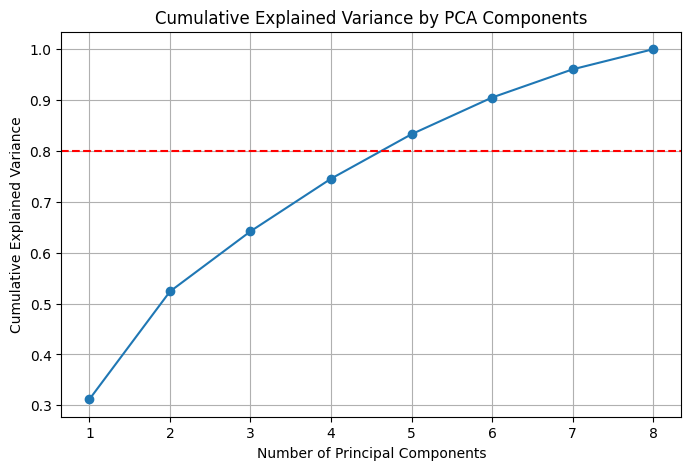

Number of components explaining at least 80% variance: 5


In [37]:
from sklearn.decomposition import PCA

# Load the dataset
df = pd.read_csv("diabetes.csv")

# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Normalize using MinMaxScaler (same as before)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
pca.fit(X_scaled)

# Compute cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Determine number of components explaining at least 80% variance
n_components_80 = np.argmax(cum_var >= 0.80) + 1
print(f"Number of components explaining at least 80% variance: {n_components_80}")



#### 2. Plot the class distribution along the first principal component and comment.

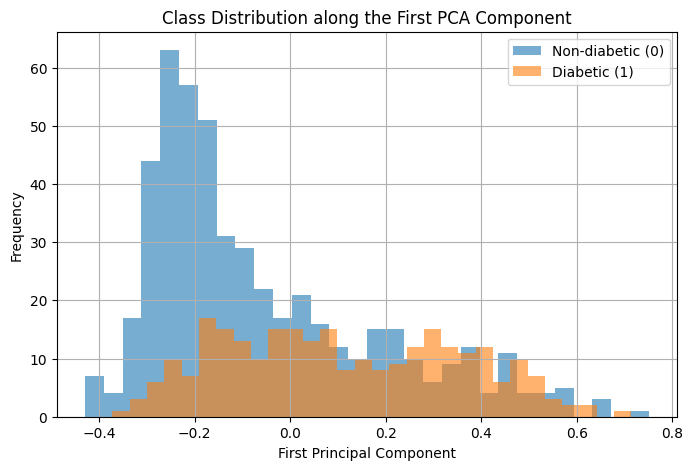

In [38]:
# Transform data using PCA
X_pca = pca.transform(X_scaled)

# Plot the class distribution along the first component
plt.figure(figsize=(8,5))
plt.hist(X_pca[y==0, 0], bins=30, alpha=0.6, label='Non-diabetic (0)')
plt.hist(X_pca[y==1, 0], bins=30, alpha=0.6, label='Diabetic (1)')
plt.title('Class Distribution along the First PCA Component')
plt.xlabel('First Principal Component')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()


 **Interpretation**: The class distribution along the first PCA component shows considerable overlap between diabetic and non-diabetic patients, indicating that PC1 does not provide clear class separation. Although it captures the greatest variance in the data, this variance is not primarily related to the class labels, so PCA alone is not effective for distinguishing between the two classes.

#### 3. Apply Linear Discriminant Analysis (LDA) and plot the class distribution along the LDA component. Comment on the results.

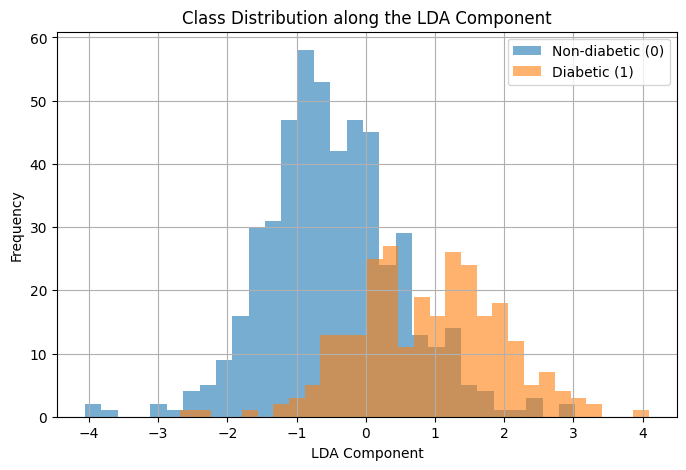

In [40]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Apply LDA (only 1 component possible since there are 2 classes)
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

# Plot class distribution along the LDA component
plt.figure(figsize=(8,5))
plt.hist(X_lda[y==0], bins=30, alpha=0.6, label='Non-diabetic (0)')
plt.hist(X_lda[y==1], bins=30, alpha=0.6, label='Diabetic (1)')
plt.title('Class Distribution along the LDA Component')
plt.xlabel('LDA Component')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()


 **Interpretation**: LDA explicitly optimized for class separation but still found the classes overlapping, suggesting that the dataset’s features do not perfectly distinguish diabetic from non-diabetic cases — hence classification may be challenging without more complex modeling.


#### 4. Which of the two methods (PCA or LDA) would be more appropriate for building a discriminant rule? Justify your answer based on the results obtained and explain why that method is more suitable.

Between the two methods, Linear Discriminant Analysis (LDA) is more appropriate for building a discriminant rule. While Principal Component Analysis (PCA) focuses on capturing the directions of maximum variance in the data without considering class labels, LDA explicitly aims to find the feature space that best separates the different classes. In this context, where the goal is to distinguish between diabetic and non-diabetic patients, using a supervised method like LDA is more suitable because it takes class information into account during dimensionality reduction.
Although the PCA plot showed a clear separation between the two classes, this occurred coincidentally due to how the variance in the data aligns with the outcome variable. PCA does not guarantee that the components it finds are optimal for discrimination. On the other hand, even though the LDA plot revealed some overlap between classes, it still provides the projection that maximizes class separability based on statistical criteria. Therefore, despite the overlap, LDA remains the more appropriate choice for developing a discriminant rule because it directly optimizes the distinction between diabetic and non-diabetic groups.